In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("dataset/retail_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Shape:")
print(df.shape)

print("\nDescriptive Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0

Dataset Shape:
(1000, 9)

Descriptive Statistics:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [4]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Check the data types after conversion
print("Updated Data Types:")
print(df.dtypes)

# Check for missing values after date conversion
print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna().copy()

print("\nCleaned Dataset Shape:", df.shape)

display(df.head())

Updated Data Types:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Cleaned Dataset Shape: (1000, 9)


C:\Users\Shaik Karimulla\AppData\Local\Temp\ipykernel_10572\3609967141.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
# Create a Month column from the Date
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Calculate total sales for each month
monthly_sales = df.groupby("Month")["Total Amount"].sum().reset_index()

# Display monthly sales
display(monthly_sales)

,Month,Total Amount
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


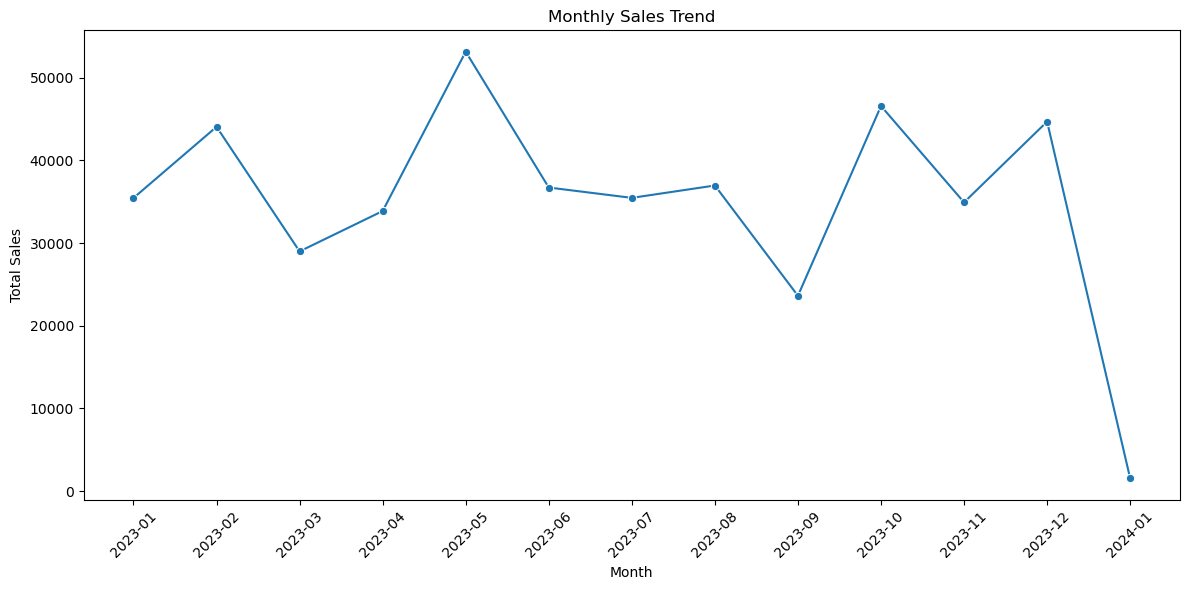

In [6]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Total Amount",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Calculate total sales by product category
category_sales = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(category_sales)

,Product Category,Total Amount
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


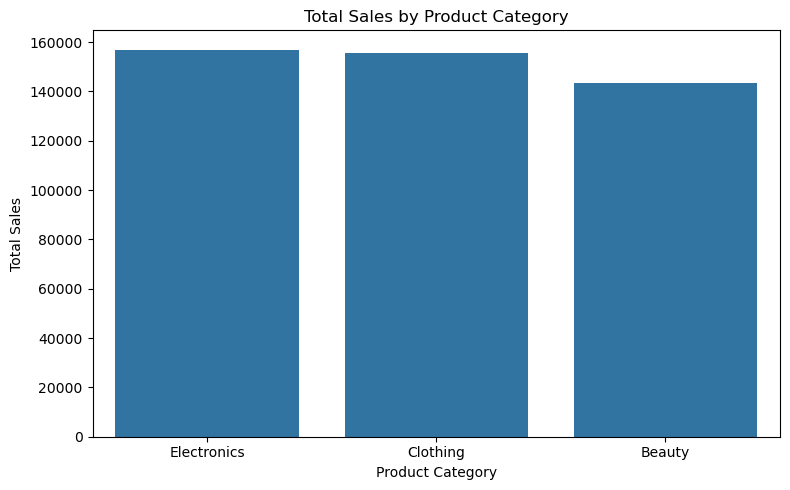

In [8]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_sales,
    x="Product Category",
    y="Total Amount"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [9]:
# Calculate total sales by gender
gender_sales = (
    df.groupby("Gender")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(gender_sales)

,Gender,Total Amount
0,Female,232840
1,Male,223160


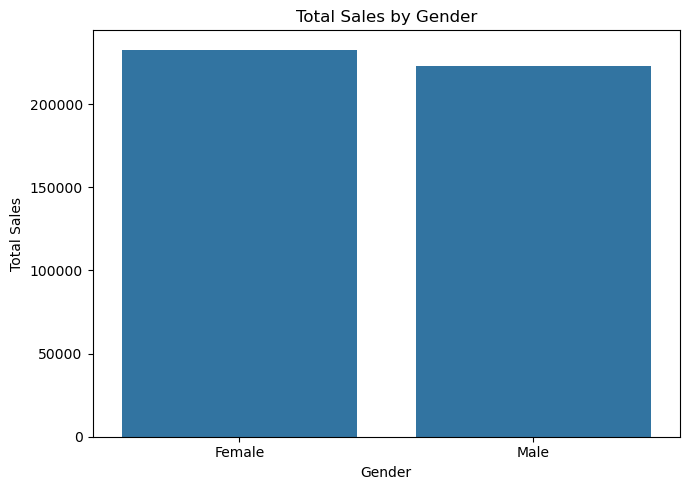

In [10]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_sales,
    x="Gender",
    y="Total Amount"
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [11]:
# Create age groups
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ["Under 18", "18-30", "31-40", "41-50", "51-60", "60+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate total sales by age group
age_group_sales = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .sum()
    .reset_index()
)

display(age_group_sales)

,Age Group,Total Amount
0,Under 18,11215
1,18-30,121730
2,31-40,95950
3,41-50,93795
4,51-60,100085
5,60+,33225


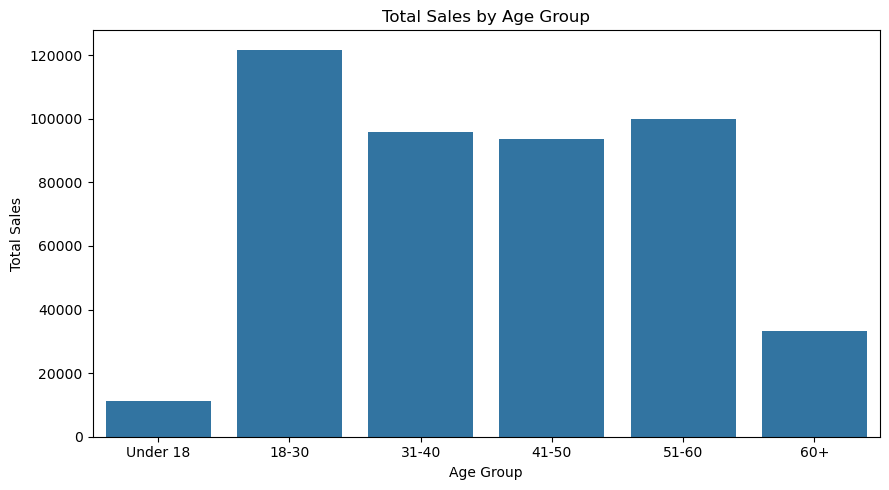

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_group_sales,
    x="Age Group",
    y="Total Amount"
)

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [13]:
# Calculate total quantity sold by product category
category_quantity = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(category_quantity)

,Product Category,Quantity
0,Clothing,894
1,Electronics,849
2,Beauty,771


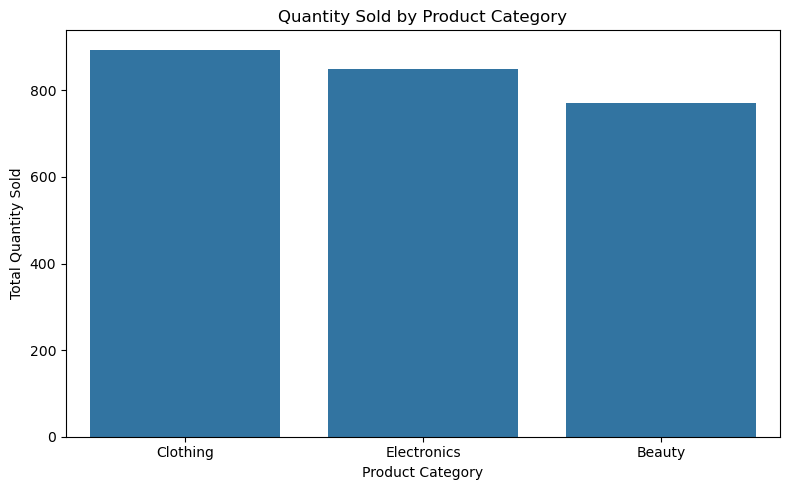

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_quantity,
    x="Product Category",
    y="Quantity"
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()

In [15]:
# Calculate customer purchase statistics by product category
category_summary = (
    df.groupby("Product Category")
    .agg(
        Total_Sales=("Total Amount", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Average_Purchase=("Total Amount", "mean"),
        Number_of_Transactions=("Transaction ID", "count")
    )
    .reset_index()
)

display(category_summary)

,Product Category,Total_Sales,Total_Quantity,Average_Purchase,Number_of_Transactions
0,Beauty,143515,771,467.475570,307
1,Clothing,155580,894,443.247863,351
2,Electronics,156905,849,458.786550,342


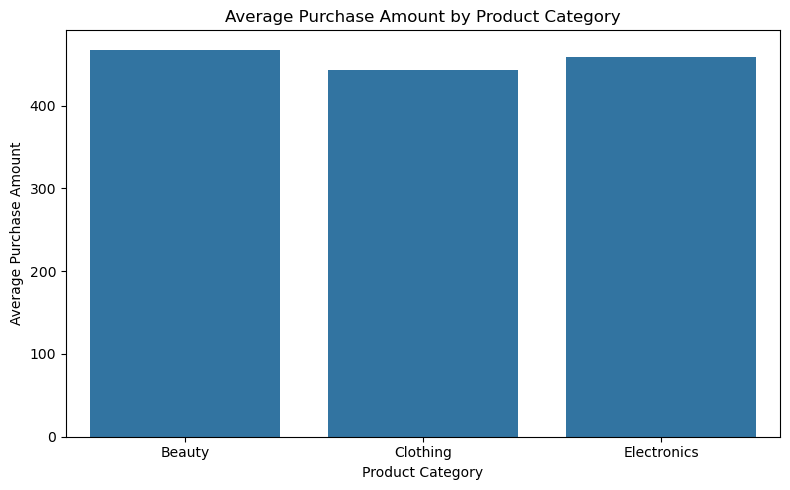

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_summary,
    x="Product Category",
    y="Average_Purchase"
)

plt.title("Average Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase Amount")
plt.tight_layout()
plt.show()

In [17]:
# Count transactions for each customer
customer_transactions = (
    df.groupby("Customer ID")["Transaction ID"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="Number of Transactions")
)

display(customer_transactions.head(10))

,Customer ID,Number of Transactions
0,CUST001,1
1,CUST671,1
2,CUST658,1
3,CUST659,1
4,CUST660,1
5,CUST661,1
6,CUST662,1
7,CUST663,1
8,CUST664,1
9,CUST665,1


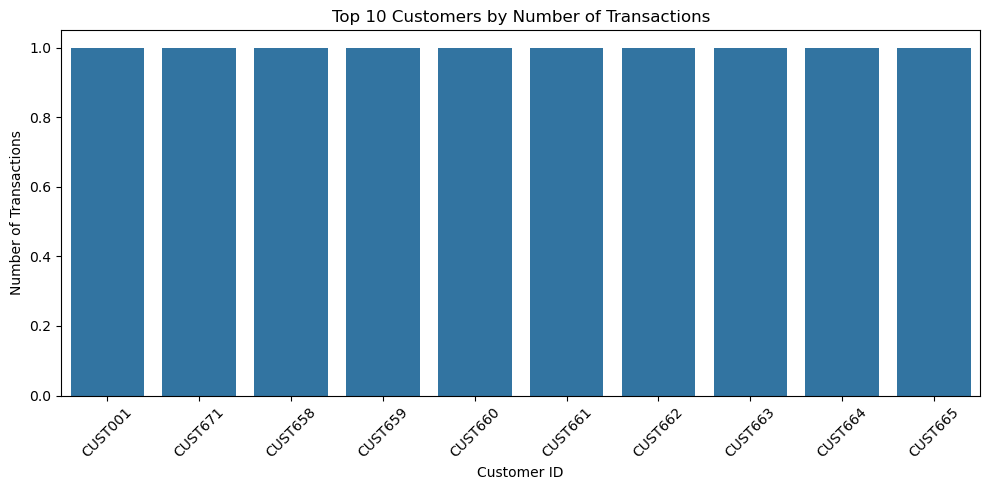

In [18]:
top_customers = customer_transactions.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_customers,
    x="Customer ID",
    y="Number of Transactions"
)

plt.title("Top 10 Customers by Number of Transactions")
plt.xlabel("Customer ID")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Calculate overall sales statistics
total_sales = df["Total Amount"].sum()
total_quantity = df["Quantity"].sum()
total_transactions = df["Transaction ID"].nunique()
average_transaction = df["Total Amount"].mean()

print("===== Overall Sales Summary =====")
print(f"Total Sales Revenue: {total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Transaction Value: {average_transaction:,.2f}")

===== Overall Sales Summary =====
Total Sales Revenue: 456,000.00
Total Quantity Sold: 2,514
Total Transactions: 1,000
Average Transaction Value: 456.00


In [20]:
# Identify key insights

best_category = category_sales.loc[category_sales["Total Amount"].idxmax(), "Product Category"]
best_category_sales = category_sales["Total Amount"].max()

best_age_group = age_group_sales.loc[
    age_group_sales["Total Amount"].idxmax(), "Age Group"
]

best_gender = gender_sales.loc[
    gender_sales["Total Amount"].idxmax(), "Gender"
]

print("===== Key Business Insights =====")
print(f"Highest Revenue Category: {best_category}")
print(f"Revenue from Best Category: {best_category_sales:,.2f}")
print(f"Highest Spending Age Group: {best_age_group}")
print(f"Gender with Higher Total Sales: {best_gender}")

===== Key Business Insights =====
Highest Revenue Category: Electronics
Revenue from Best Category: 156,905.00
Highest Spending Age Group: 18-30
Gender with Higher Total Sales: Female


In [21]:
# Calculate monthly sales for each product category
monthly_category_sales = (
    df.groupby(["Month", "Product Category"])["Total Amount"]
    .sum()
    .reset_index()
)

display(monthly_category_sales.head(15))

,Month,Product Category,Total Amount
0,2023-01,Beauty,12430
1,2023-01,Clothing,13125
2,2023-01,Electronics,9895
3,2023-02,Beauty,14035
4,2023-02,Clothing,14560
5,2023-02,Electronics,15465
6,2023-03,Beauty,10545
7,2023-03,Clothing,15065
8,2023-03,Electronics,3380
9,2023-04,Beauty,11905


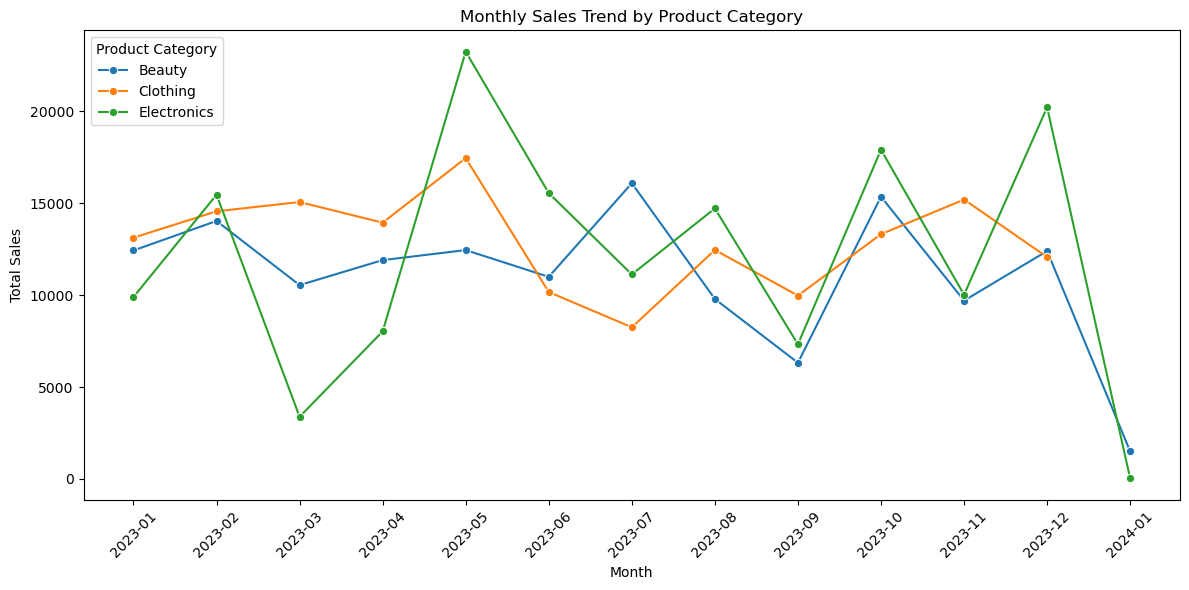

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_category_sales,
    x="Month",
    y="Total Amount",
    hue="Product Category",
    marker="o"
)

plt.title("Monthly Sales Trend by Product Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.tight_layout()
plt.show()

In [23]:
# Find the category with the highest total sales

best_category_row = category_sales.loc[
    category_sales["Total Amount"].idxmax()
]

print("Best-Selling Product Category:")
print(best_category_row["Product Category"])

print(
    f"Total Sales: {best_category_row['Total Amount']:,.2f}"
)

Best-Selling Product Category:
Electronics
Total Sales: 156,905.00


In [24]:
# Find the transaction with the highest total amount

highest_transaction = df.loc[
    df["Total Amount"].idxmax()
]

print("===== Highest Value Transaction =====")
print(f"Transaction ID: {highest_transaction['Transaction ID']}")
print(f"Customer ID: {highest_transaction['Customer ID']}")
print(f"Product Category: {highest_transaction['Product Category']}")
print(f"Quantity: {highest_transaction['Quantity']}")
print(f"Total Amount: {highest_transaction['Total Amount']:,.2f}")

===== Highest Value Transaction =====
Transaction ID: 15
Customer ID: CUST015
Product Category: Electronics
Quantity: 4
Total Amount: 2,000.00


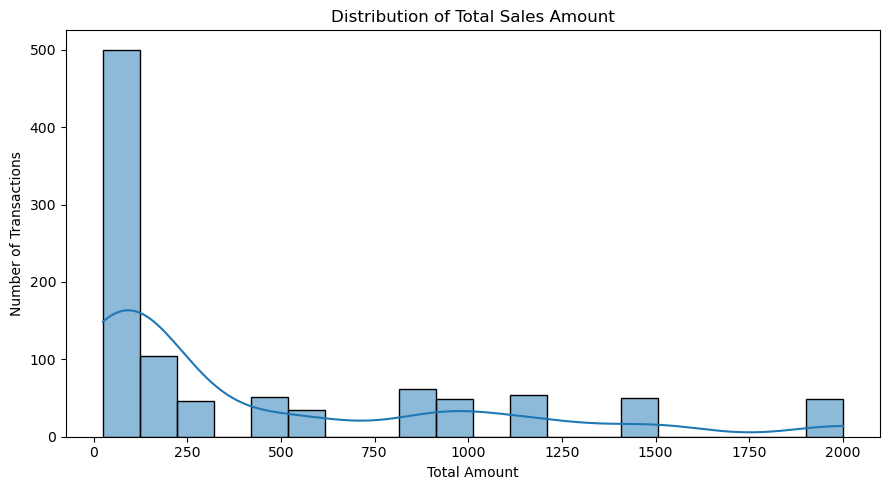

In [25]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Total Amount",
    bins=20,
    kde=True
)

plt.title("Distribution of Total Sales Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [26]:
print("========== RETAIL SALES ANALYSIS SUMMARY ==========")

print(f"Total Revenue: {df['Total Amount'].sum():,.2f}")
print(f"Total Quantity Sold: {df['Quantity'].sum():,}")
print(f"Total Transactions: {df['Transaction ID'].nunique():,}")
print(f"Average Transaction Value: {df['Total Amount'].mean():,.2f}")

print(f"\nBest-Selling Category: {best_category}")
print(f"Highest Spending Age Group: {best_age_group}")
print(f"Gender with Higher Sales: {best_gender}")

print("\nAnalysis completed successfully!")

========== RETAIL SALES ANALYSIS SUMMARY ==========
Total Revenue: 456,000.00
Total Quantity Sold: 2,514
Total Transactions: 1,000
Average Transaction Value: 456.00

Best-Selling Category: Electronics
Highest Spending Age Group: 18-30
Gender with Higher Sales: Female

Analysis completed successfully!


# Retail Sales Analysis

## Introduction

This project focuses on analyzing retail sales data to identify important
patterns and business insights.

The analysis examines sales trends over time, product category performance,
customer demographics, purchasing behavior, and transaction values.

Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn are used
for data cleaning, exploratory data analysis, visualization, and insight
generation.

## Key Findings

- Monthly sales trends were analyzed to understand changes in revenue over time.
- Product categories were compared based on total revenue and quantity sold.
- Sales performance was analyzed by gender.
- Customer age groups were compared to identify higher-spending groups.
- Customer transaction frequency was analyzed to identify frequent customers.
- Average transaction value was calculated to understand customer spending behavior.
- The highest-value transaction and best-performing product category were identified.
- Multiple visualizations were created to make the findings easier to understand.

## Conclusion

The Retail Sales Analysis project provided useful insights into customer
purchasing behavior and overall sales performance.

The dataset was cleaned and explored using statistical analysis and
visualizations. Sales trends, product categories, customer demographics,
quantity sold, transaction frequency, and purchase values were analyzed.

These insights can help businesses understand their customers, identify
strong-performing product categories, monitor sales trends, and make
data-driven business decisions.

Overall, this project demonstrates the use of Python for practical retail
sales analysis and exploratory data analysis.